# label-transfer-tissdiss-v2
Transfer `manual_map_leiden` from old object by barcode match; celltypist for new cells.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.neighbors import KNeighborsClassifier

In [2]:
adata = sc.read_h5ad('files/processed-subset-tissdiss-v2.h5ad')

In [3]:
# build label map from old object — keyed on original_barcode (pre-uniquify suffix)
old_labels = pd.read_parquet("files/old_labels.parquet")['manual_map_leiden'].to_dict()
# new object has original_barcode stored before obs_names_make_unique
adata.obs['manual_map_leiden'] = adata.obs['original_barcode'].map(old_labels)

matched   = adata.obs['manual_map_leiden'].notna().sum()
unmatched = adata.obs['manual_map_leiden'].isna().sum()
print(f"Matched: {matched} | Unmatched (new cells): {unmatched}")

Matched: 353487 | Unmatched (new cells): 361426


In [4]:
# KNN label transfer for unmatched (new) cells in shared Harmony PCA space
LATENT_KEY  = 'X_pca'   # swapped to X_pca_harmony in build notebook
N_NEIGHBORS = 100

X = adata.obsm[LATENT_KEY]
labels = adata.obs['manual_map_leiden'].copy()
known  = labels.notna()
unknown = labels.isna()

knn = KNeighborsClassifier(n_neighbors=N_NEIGHBORS, weights='distance', n_jobs=-1)
knn.fit(X[known], labels[known])

adata.obs.loc[unknown, 'manual_map_leiden'] = knn.predict(X[unknown])

proba = knn.predict_proba(X[unknown])
adata.obs['knn_confidence'] = np.nan
adata.obs.loc[unknown, 'knn_confidence'] = proba.max(axis=1)

print("KNN predictions:")
print(adata.obs.loc[unknown, 'manual_map_leiden'].value_counts())
print(adata.obs.loc[unknown, 'knn_confidence'].describe())

KNN predictions:
manual_map_leiden
MM-PC3                           166256
MM-PC1                            56531
MM-Proliferative-1                28936
CTL                               27696
MM-PC2                            19961
Monocyte/Macrophage               15260
BMSC/CAF                          13162
MM-PC4                             8768
Tumor Infiltrating Lymphocyte      8546
Immature Neutrophil                5566
Endothelial                        3686
MM-Proliferative-2                 2758
NK                                 2066
B Cell                             1543
Proliferative NK                    595
Neutrophil                           96
Name: count, dtype: int64
count    361426.000000
mean          0.524677
std           0.206310
min           0.137248
25%           0.347000
50%           0.502236
75%           0.687097
max           1.000000
Name: knn_confidence, dtype: float64


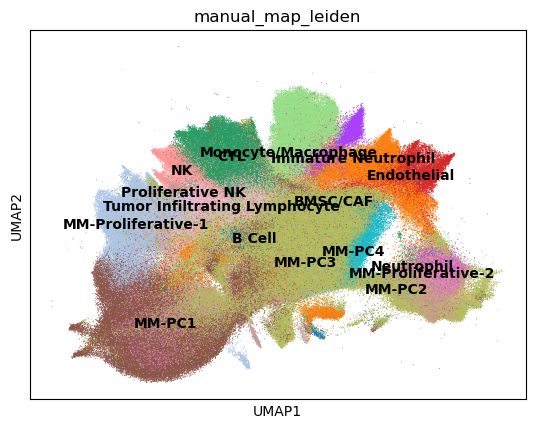

In [5]:
sc.pl.umap(adata, color='manual_map_leiden', size=2, legend_loc='on data')

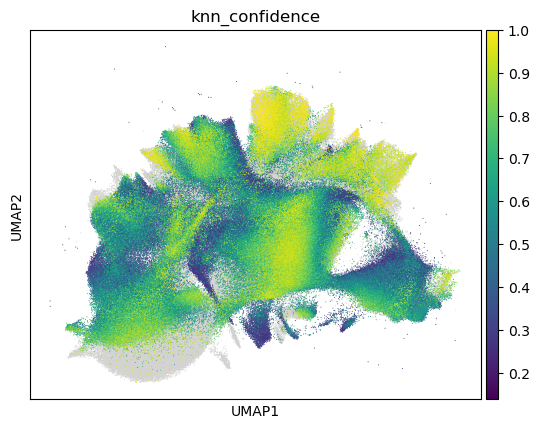

In [10]:
sc.pl.umap(adata, color='knn_confidence', size=2, legend_loc='on data')

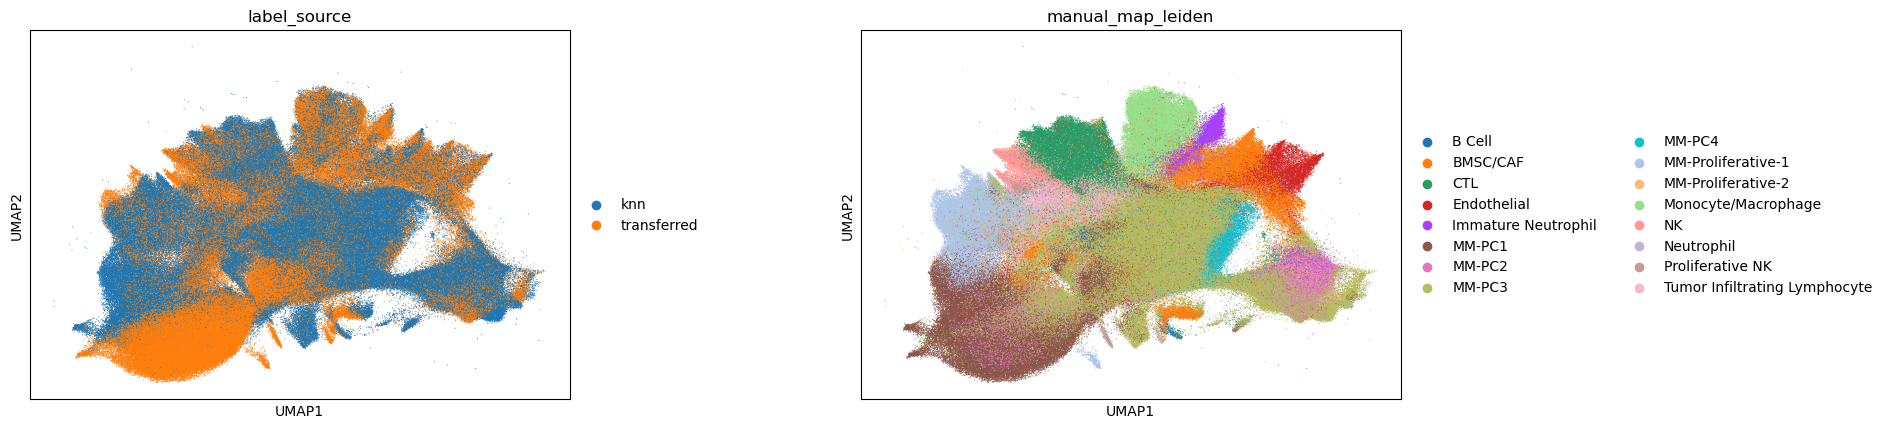

In [7]:
# split by source to verify new cells cluster sensibly
adata.obs['label_source'] = np.where(
    adata.obs['original_barcode'].isin(old_labels), 'transferred', 'knn'
)
sc.pl.umap(adata, color=['label_source', 'manual_map_leiden'], size=2, wspace=0.4)

In [8]:
adata.write('files/labelled-tissdiss-v2.h5ad')
raw_ad = sc.read_h5ad('files/raw-all-tissdiss-v2.h5ad')

In [11]:
raw_ad = raw_ad[adata.obs_names]
raw_ad.obs['manual_map_leiden'] = adata.obs['manual_map_leiden']

/tmp/ipykernel_9045/2009570445.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  raw_ad.obs['manual_map_leiden'] = adata.obs['manual_map_leiden']


In [12]:
raw_ad

AnnData object with n_obs × n_vars = 714913 × 18593
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'manual_map_leiden'

In [13]:
raw_ad.raw = raw_ad

In [15]:
# gene-level filters — no HB mask (consistent with plasma-tissdiss-paga)
raw_ad = raw_ad[raw_ad.X.sum(axis=1) > 0]

mt_mask   = raw_ad.var_names.str.startswith('MT-')
ribo_mask = raw_ad.var_names.str.startswith(('RPS', 'RPL'))
ig_mask   = raw_ad.var_names.str.startswith(('IGK', 'IGL', 'IGH'))

raw_ad = raw_ad[:, ~(mt_mask | ribo_mask | ig_mask)]
raw_ad

View of AnnData object with n_obs × n_vars = 714913 × 18569
    obs: 'source_file', 'TIS_ID', 'project', 'original_barcode', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'manual_map_leiden'

In [16]:
sc.pp.normalize_total(raw_ad)
sc.pp.log1p(raw_ad)
sc.pp.highly_variable_genes(raw_ad, min_mean=0.0125, max_mean=3, min_disp=0.25)
sc.pp.scale(raw_ad, max_value=10, zero_center=False)
sc.tl.pca(raw_ad, svd_solver='arpack')
raw_ad.obsm['X_pca_temp'] = raw_ad.obsm['X_pca']

/tmp/ipykernel_9045/1915166987.py:1: UserWarning: Received a view of an AnnData. Making a copy.
  sc.pp.normalize_total(raw_ad)


In [17]:
import harmonypy
ho = harmonypy.run_harmony(raw_ad.obsm['X_pca'].astype('float64'),
                           raw_ad.obs, 'source_file')
raw_ad.obsm['X_pca'] = ho.Z_corr

2026-08-04 22:02:02,653 - harmonypy - INFO - Running Harmony
2026-08-04 22:02:02,654 - harmonypy - INFO -   Parameters:
2026-08-04 22:02:02,654 - harmonypy - INFO -     max_iter_harmony: 10
2026-08-04 22:02:02,654 - harmonypy - INFO -     max_iter_kmeans: 4
2026-08-04 22:02:02,655 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-08-04 22:02:02,655 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-08-04 22:02:02,655 - harmonypy - INFO -     nclust: 100
2026-08-04 22:02:02,656 - harmonypy - INFO -     block_size: 0.05
2026-08-04 22:02:02,657 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-08-04 22:02:02,657 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-08-04 22:02:02,658 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.

In [18]:
sc.pp.neighbors(raw_ad)
sc.tl.umap(raw_ad)
sc.tl.leiden(raw_ad, resolution=1.5, n_iterations=2)

/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
/tmp/ipykernel_9045/1932612063.py:3: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(raw_ad, resolution=1.5, n_iterations=2)


In [19]:
sc.tl.rank_genes_groups(raw_ad, 
                        'manual_map_leiden', 
                        method='t-test', 
                        key_added = 't-test', 
                        use_raw = False)

In [20]:
result = raw_ad.uns['t-test']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:5]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj', 'scores']})

threshold = 0.05
significant_mask = pd.concat(
    [df[group + '_pvals'] < threshold for group in groups], axis=1).any(axis=1)
significant_df = df[significant_mask]
significant_df.head()
significant_df.to_csv('files/manual_labels_rank_genes.csv')

In [21]:
sc.tl.rank_genes_groups(raw_ad, 
                        'leiden', 
                        method='t-test', 
                        key_added = 't-test', 
                        use_raw = False)

result = raw_ad.uns['t-test']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:5]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj', 'scores']})

threshold = 0.05
significant_mask = pd.concat(
    [df[group + '_pvals'] < threshold for group in groups], axis=1).any(axis=1)
significant_df = df[significant_mask]
significant_df.head()
significant_df.to_csv('files/leiden_rank_genes.csv')

/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:607: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/home/workspace/spatial-pcd-data-release/.pixi/envs/default/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/home/workspace/spatial-pcd-data-release/.pixi/envs/default/l

In [ ]:
sc.tl.dendrogram(raw_ad, groupby='leiden')
sc.pl.rank_genes_groups_dotplot(raw_ad, n_genes=4, key='t-test', groupby='leiden')

In [22]:
raw_ad.write('files/iter2-tissdiss-redo.h5ad')